<a href="https://colab.research.google.com/github/hariharan0493/Task2_Submission/blob/main/level2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pickle
import numpy as np
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns

In [2]:
#device configuration
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
#Parameters
num_epochs = 15
batch_size = 64
learning_rate = 0.001
hidden_size=64
input_size=3
output_size=12
momentum=0.9

In [4]:
seq_len=84
all_slice=[]
df=pd.read_csv('/content/data/jena_climate_2009_2016.csv')
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df.set_index('Date Time', inplace=True)

df = df.interpolate(method='linear')
hourly_df = df.resample('H').mean()
feature_cols = ['T (degC)', 'rh (%)', 'p (mbar)']
df_filtered = hourly_df[feature_cols]

df_filtered = df_filtered.dropna()

#normalising
scaler = StandardScaler()
df_filtered_scaled = scaler.fit_transform(df_filtered)
raw_data = scaler.fit_transform(df_filtered.values)

feature_cols = ['T (degC)', 'rh (%)', 'p (mbar)']

for i in range(len(df_filtered)-seq_len+1):
  slice=raw_data[i:i+seq_len]
  all_slice.append(slice)

all_slice = np.array(all_slice)

x_all=all_slice[:,:72,:]
y_all=all_slice[:,72:,0]

total_samples = len(x_all)
train_end = int(total_samples * 0.8)  # 80% Train, 20% Test

x_train = x_all[:train_end]
y_train = y_all[:train_end]

x_test = x_all[train_end:]
y_test = y_all[train_end:]

x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for batch_x, batch_y in train_loader:
    print(f"Train Batch X shape: {batch_x.shape}") # Expected: (64, 72, 3)
    print(f"Train Batch y shape: {batch_y.shape}") # Expected: (64, 12)
    break

for batch_x, batch_y in test_loader:
    print(f"Test Batch X shape: {batch_x.shape}") # Expected: (64, 72, 3)
    print(f"Test Batch y shape: {batch_y.shape}") # Expected: (64, 12)
    break

/tmp/ipykernel_1147/2777396166.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = df.resample('H').mean()


Train Batch X shape: torch.Size([64, 72, 3])
Train Batch y shape: torch.Size([64, 12])
Test Batch X shape: torch.Size([64, 72, 3])
Test Batch y shape: torch.Size([64, 12])


In [5]:
class LSTMCell(nn.Module):
  def __init__(self,input_size,hiddlen_size):
    super().__init__()

    self.hidden_size=hiddlen_size

    self.Wf = nn.Linear(input_size + hidden_size, hidden_size)
    self.Wi = nn.Linear(input_size + hidden_size, hidden_size)
    self.Wc = nn.Linear(input_size + hidden_size, hidden_size)
    self.Wo = nn.Linear(input_size + hidden_size, hidden_size)

  def forward(self, x, h_prev, c_prev):

    combined = torch.cat((x, h_prev), dim=1)
    f = torch.sigmoid(self.Wf(combined))
    i = torch.sigmoid(self.Wi(combined))
    g = torch.tanh(self.Wc(combined))
    o = torch.sigmoid(self.Wo(combined))
    c = f * c_prev + i * g
    h = o * torch.tanh(c)

    return h, c

class WeatherForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
      super().__init__()
      self.hidden_size = hidden_size
      output_size=output_size
      self.lstm_cell = LSTMCell(input_size, hidden_size)
      self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
      # x shape expects: (batch_size, sequence_length, input_size)
      batch_size, seq_leng, _ = x.size()

      h = torch.zeros(batch_size, self.hidden_size, device=x.device)
      c = torch.zeros(batch_size, self.hidden_size, device=x.device)

      for t in range(seq_leng):
        x_t = x[:, t, :]
        h, c = self.lstm_cell(x_t, h, c)

      predictions = self.fc(h)
      return predictions


In [6]:
model=WeatherForecaster(input_size,hidden_size,output_size).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate,momentum=momentum)

In [7]:
#Lists
train_losses=list()
train_accuracies=list()
val_losses=list()
val_accuracies=list()

In [8]:
# Train the model
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
  model.train()
  epoch_loss = 0
  n_correct = 0
  n_samples = 0

  for i, (x, y) in enumerate(train_loader):
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    predictions = model(x)
    loss = criterion(predictions, y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    epoch_loss += loss.item()
    correct = (torch.abs(predictions - y) <= 1)
    n_samples += y.numel()
    n_correct += correct.sum().item()

    if (i + 1) % 100 == 0:
      print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

  train_acc = 100 * n_correct / n_samples
  train_loss = epoch_loss / len(train_loader)

  # Test the model (Validation)
  model.eval()
  val_loss = 0
  val_n_correct = 0
  val_n_samples = 0
  all_actuals = []
  all_preds = []

  with torch.no_grad():
    for x, y in test_loader:
      x = x.to(device)
      y = y.to(device)

      outputs = model(x)
      val_loss += criterion(outputs, y).item()

      predicted = (torch.abs(outputs - y) <= 1)
      val_n_samples += y.numel()
      val_n_correct += predicted.sum().item()

      # Save for Classification Metrics
      all_actuals.append(y.cpu().numpy())
      all_preds.append(outputs.cpu().numpy())

  val_acc = 100.0 * val_n_correct / val_n_samples
  val_loss = val_loss / len(test_loader)

  # Save the values to list
  train_losses.append(train_loss)
  train_accuracies.append(train_acc)
  val_accuracies.append(val_acc)
  val_losses.append(val_loss)

  print(f'Epoch [{epoch+1}/{num_epochs}], Train_acc: {train_acc:.4f}%, Train_loss: {train_loss:.4f}, Val_acc: {val_acc:.4f}%, Val_loss: {val_loss:.4f}')

print('Finished Training')
torch.save(model.state_dict(), 'model_weights.pth')

Epoch [1/15], Step [100/875], Loss: 0.8794
Epoch [1/15], Step [200/875], Loss: 0.7122
Epoch [1/15], Step [300/875], Loss: 0.8961
Epoch [1/15], Step [400/875], Loss: 0.7237
Epoch [1/15], Step [500/875], Loss: 0.5966
Epoch [1/15], Step [600/875], Loss: 0.6711
Epoch [1/15], Step [700/875], Loss: 0.3778
Epoch [1/15], Step [800/875], Loss: 0.2699
Epoch [1/15], Train_acc: 77.5874%, Train_loss: 0.6920, Val_acc: 91.7763%, Val_loss: 0.3048
Epoch [2/15], Step [100/875], Loss: 0.2871
Epoch [2/15], Step [200/875], Loss: 0.3259
Epoch [2/15], Step [300/875], Loss: 0.2155
Epoch [2/15], Step [400/875], Loss: 0.2782
Epoch [2/15], Step [500/875], Loss: 0.2365
Epoch [2/15], Step [600/875], Loss: 0.1883
Epoch [2/15], Step [700/875], Loss: 0.2372
Epoch [2/15], Step [800/875], Loss: 0.2539
Epoch [2/15], Train_acc: 94.2729%, Train_loss: 0.2548, Val_acc: 94.6702%, Val_loss: 0.2440
Epoch [3/15], Step [100/875], Loss: 0.2791
Epoch [3/15], Step [200/875], Loss: 0.2711
Epoch [3/15], Step [300/875], Loss: 0.2026
E


--- Classification Report ---
              precision    recall  f1-score   support

    Freezing       0.74      0.74      0.74     16356
        Cold       0.80      0.82      0.81     55746
    Moderate       0.80      0.78      0.79     59538
        Warm       0.83      0.84      0.84     36264

    accuracy                           0.80    167904
   macro avg       0.79      0.79      0.79    167904
weighted avg       0.80      0.80      0.80    167904



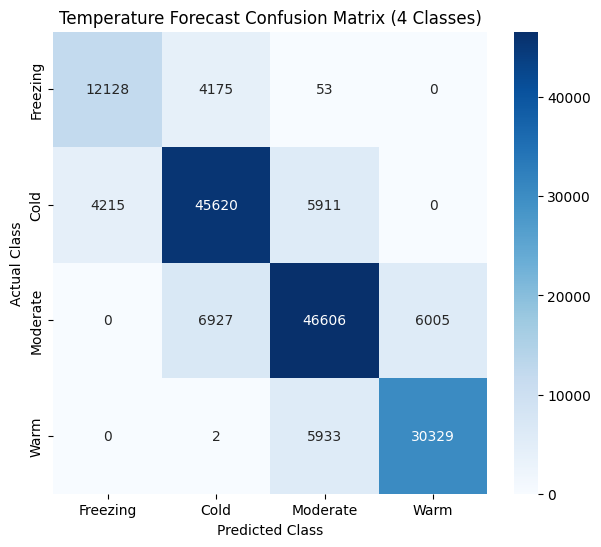

In [10]:
#Adding Classification Metrics after training completion
actuals_flat = np.concatenate(all_actuals).flatten()
preds_flat = np.concatenate(all_preds).flatten()

# Thresholds: -1.0, 0, 1.0
bins = [-np.inf, -1.0, 0, 1.0, np.inf]
y_true_class = np.digitize(actuals_flat, bins) - 1
y_pred_class = np.digitize(preds_flat, bins) - 1

target_names = ["Freezing", "Cold", "Moderate", "Warm"]

print("\n--- Classification Report ---")
report = classification_report(y_true_class,y_pred_class, target_names=target_names)
print(report)

with open('../classification_report.txt', 'w') as f:
    f.write(report)

#Confusion Matrix
cm = confusion_matrix(y_true_class, y_pred_class)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Temperature Forecast Confusion Matrix (4 Classes)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.savefig('confusion_matrix.png')
plt.show()

In [11]:
#submission.csv
submission = pd.DataFrame({
    'id': range(len(preds_flat)),
    'prediction': preds_flat
})

submission.to_csv('submission.csv', index=False)
print("submission.csv generated successfully!")

submission.csv generated successfully!


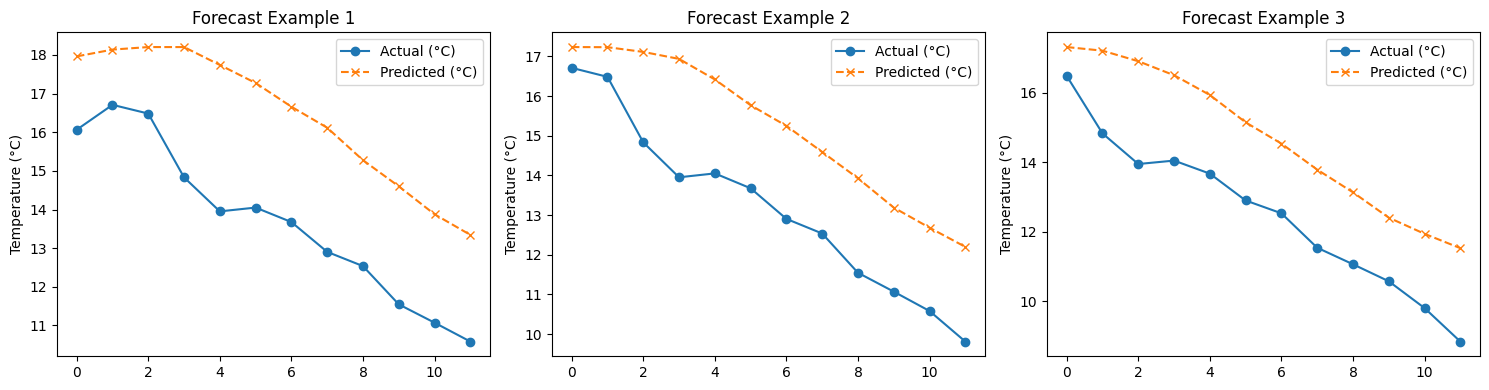

In [19]:
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        predictions = model(x)

        # arrays for inverse transform
        actual_raw = y.cpu().numpy()
        pred_raw = predictions.cpu().numpy()

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for i in range(3):

            actual_dummy = np.zeros((12, 3))
            actual_dummy[:, 0] = actual_raw[i]

            pred_dummy = np.zeros((12, 3))
            pred_dummy[:, 0] = pred_raw[i]

            # Inverse transform
            actual_final = scaler.inverse_transform(actual_dummy)[:, 0]
            pred_final = scaler.inverse_transform(pred_dummy)[:, 0]

            axes[i].plot(actual_final, label='Actual (°C)', marker='o')
            axes[i].plot(pred_final, label='Predicted (°C)', marker='x', linestyle='--')
            axes[i].set_title(f"Forecast Example {i+1}")
            axes[i].set_ylabel("Temperature (°C)")
            axes[i].legend()
            axes[i].figure.savefig(f"Forecast_Example{i+1}.png")

        plt.tight_layout()
        plt.show()
        break

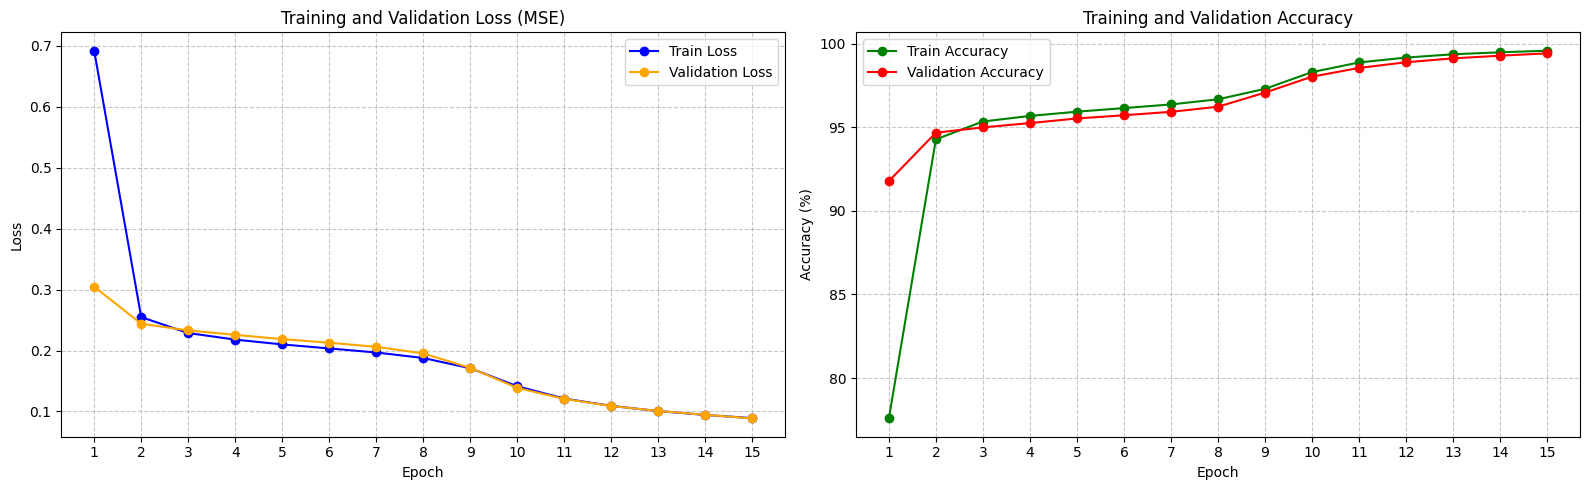

In [21]:
# calculate the number of epochs based on actual training data
num_data_points = len(train_losses)
epochs = range(1, num_data_points + 1)

# Create the figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: MSE Loss ---
ax1.plot(epochs, train_losses, marker='o', label='Train Loss', color='blue')
ax1.plot(epochs, val_losses, marker='o', label='Validation Loss', color='orange')
ax1.set_title("Training and Validation Loss (MSE)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xticks(epochs)
ax1.legend()
ax1.figure.savefig('Loss_curves.png')
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy
ax2.plot(epochs, train_accuracies, marker='o', label='Train Accuracy', color='green')
ax2.plot(epochs, val_accuracies, marker='o', label='Validation Accuracy', color='red')
ax2.set_title("Training and Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_xticks(epochs)
ax2.legend()
ax2.figure.savefig('Accuracy_curves.png')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [22]:
from google.colab import files

files.download("model_weights.pth")
files.download('../classification_report.txt')
files.download("submission.csv")
files.download("confusion_matrix.png")
files.download("Loss_curves.png")
files.download("Accuracy_curves.png")

for i in range(3):
  files.download(f"Forecast_Example{i+1}.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>